이번 대회에서는 범주형 변수 전처리를 위해 Label Encoding과 for문을 사용했습니다.  

이는 train data로 fit한 Label Encoder로 test data를 transform할 경우,  

train data에는 속하지 않은 데이터가 test data에 있을 가능성이 있어 에러가 발생할 수 있기 때문입니다.  

이를 방지하기 위해 for문을 사용하여 예외적인 상황에 대처할 수 있도록 코드를 작성했습니다.  

참고해 주시길 바랍니다.  

# import / 라이브러리 호출

In [74]:
! pip install lightgbm
! pip install xgboost
! pip install optuna


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [optuna]2m4/5 [optuna]]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [76]:
import pandas as pd
import random
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error

from lightgbm import LGBMRegressor, plot_importance
from xgboost import XGBRegressor, plot_importance



# Fixed RandomSeed / 랜덤시드 고정
매번 고정된 결과를 얻기 위해서 사용합니다.  

seed를 고정하지 않는다면 같은 코드라도 매번 다른 결과가 나오게됩니다.  

항상 동일한 결과를 얻기 위해서 사용합니다.

In [46]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(42) # Seed 고정

# Data Load / 데이터 불러오기

In [47]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [48]:
print("train shape:", train.shape)
print("test shape :", test.shape)
print("train is test?", train is test)
print("train==test head?\n", train.head(2), "\n---\n", test.head(2))

train shape: (7500, 11)
test shape : (7500, 10)
train is test? False
train==test head?
            ID  Exercise_Duration  Body_Temperature(F)    BPM  Height(Feet)  \
0  TRAIN_0000               26.0                105.6  107.0           5.0   
1  TRAIN_0001                7.0                103.3   88.0           6.0   

   Height(Remainder_Inches)  Weight(lb)  Weight_Status Gender  Age  \
0                       9.0       154.3  Normal Weight      F   45   
1                       6.0       224.9     Overweight      M   50   

   Calories_Burned  
0            166.0  
1             33.0   
---
           ID  Exercise_Duration  Body_Temperature(F)    BPM  Height(Feet)  \
0  TEST_0000               26.0                105.1  107.0           5.0   
1  TEST_0001               29.0                104.9  111.0           6.0   

   Height(Remainder_Inches)  Weight(lb)  Weight_Status Gender  Age  
0                       1.0       114.6  Normal Weight      F   45  
1                       2.0

In [49]:
display(train.head())
print(train.columns)

,ID,Exercise_Duration,Body_Temperature(F),BPM,Height(Feet),Height(Remainder_Inches),Weight(lb),Weight_Status,Gender,Age,Calories_Burned
0,TRAIN_0000,26.0,105.6,107.0,5.0,9.0,154.3,Normal Weight,F,45,166.0
1,TRAIN_0001,7.0,103.3,88.0,6.0,6.0,224.9,Overweight,M,50,33.0
2,TRAIN_0002,7.0,103.3,86.0,6.0,3.0,218.3,Overweight,M,29,23.0
3,TRAIN_0003,17.0,104.0,99.0,5.0,6.0,147.7,Normal Weight,F,33,91.0
4,TRAIN_0004,9.0,102.7,88.0,5.0,10.0,169.8,Normal Weight,M,38,32.0


Index(['ID', 'Exercise_Duration', 'Body_Temperature(F)', 'BPM', 'Height(Feet)',
       'Height(Remainder_Inches)', 'Weight(lb)', 'Weight_Status', 'Gender',
       'Age', 'Calories_Burned'],
      dtype='object')


# Feature & Target Split / 독립변수, 종속변수로 나누기  

모델을 학습시키기 위해서 독립변수(x)와 종속변수(y)로 나누어야 합니다.  

단, 분석에 활용될 수 없는 ID 데이터는 제거하겠습니다.

데이터 타입:
ID                           object
Exercise_Duration           float64
Body_Temperature(F)         float64
BPM                         float64
Height(Feet)                float64
Height(Remainder_Inches)    float64
Weight(lb)                  float64
Weight_Status                object
Gender                       object
Age                           int64
Calories_Burned             float64
dtype: object

결측치: 0

타겟 분포:
count    7500.000000
mean       89.373467
std        62.817086
min         1.000000
25%        35.000000
50%        77.000000
75%       138.000000
max       300.000000
Name: Calories_Burned, dtype: float64


<Axes: xlabel='Calories_Burned', ylabel='Count'>

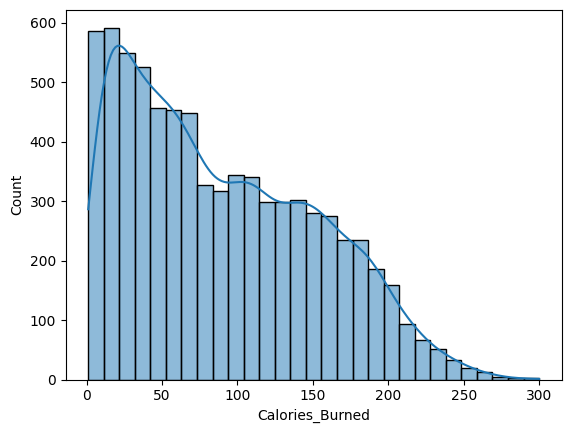

In [50]:
print('데이터 타입:')
print(train.dtypes)
print(f'\n결측치: {train.isnull().sum().sum()}')
print(f'\n타겟 분포:')
print(train['Calories_Burned'].describe())
sns.histplot(train['Calories_Burned'], kde=True)


In [51]:
# 독립변수로 설정할 train_x에서는 종속변수를 제거합니다. 또한 분석에 활용하지 않는 ID 데이터를 제거합니다.
train_x = train.drop(['ID', 'Calories_Burned'], axis = 1)
# train_y 변수를 종속변수로 사용하기 위해 Calories_Burned 데이터를 지정하였습니다.
train_y = train['Calories_Burned']

# train_x 데이터와 마찬가지로 분석에 활용하지 않는 ID 데이터를 제거합니다.
test_x = test.drop('ID', axis = 1)


# Data Preprocessing / 데이터 전처리  

데이터 전처리는 결측치 제거, 데이터 단위 변환 등 데이터에 여러 가지 처리를 해주는 것입니다.  

전처리를 함으로써 데이터 분석이 가능하기 때문에 데이터 분석에 있어서 반드시 필수적인 부분입니다.  

이번 Baseline 코드에서 사용할 전처리 방법은 Label Encoding 입니다.

범주형 변수는 순차형 변수와 명목형 변수로 나눌 수 있습니다. 

명목형 변수는 순서 관계가 존재하지 않기 때문에 수치 레이블링(Labeling)으로는 관계를 제대로 표현할 수 없으나,  

순차형 변수의 경우 순서대로 수치값을 레이블로 부여하여 간단히 수치화 할 수 있습니다.   

따라서 Label Encoding 방법을 사용하여 문자열 데이터를 변환하겠습니다.

In [52]:
#범주형 변수 인코딩 One-Hot Encoding (X에만!)
# 겟더미로 가져와서 변수 생성(순서 없는 명목형 범주는 One-Hot이 안전)
# 카테고리를 독립적인 변수로 만들어서 순서x,크기왜곡x,모델이 오해x
# LabelEncoder 사용시 숫자 크기에따라 학습시 의미가 생겨버릴수있음 특히 Weight_Status때문에..
train_x = pd.get_dummies(train_x, columns=['Gender', 'Weight_Status'], drop_first=True)
test_x = pd.get_dummies(test_x, columns=['Gender', 'Weight_Status'], drop_first=True)

# train / test 컬럼 맞추기
train_x, test_x = train_x.align(test_x, join='left', axis=1, fill_value=0)
test_x = test_x[train_x.columns]  # train 컬럼 순서대로 맞춤



In [53]:
print(train_x.shape)
print(test_x.shape)
print(train_y.shape)
print(train.head())
print(test.head())

(7500, 10)
(7500, 10)
(7500,)
           ID  Exercise_Duration  Body_Temperature(F)    BPM  Height(Feet)  \
0  TRAIN_0000               26.0                105.6  107.0           5.0   
1  TRAIN_0001                7.0                103.3   88.0           6.0   
2  TRAIN_0002                7.0                103.3   86.0           6.0   
3  TRAIN_0003               17.0                104.0   99.0           5.0   
4  TRAIN_0004                9.0                102.7   88.0           5.0   

   Height(Remainder_Inches)  Weight(lb)  Weight_Status Gender  Age  \
0                       9.0       154.3  Normal Weight      F   45   
1                       6.0       224.9     Overweight      M   50   
2                       3.0       218.3     Overweight      M   29   
3                       6.0       147.7  Normal Weight      F   33   
4                      10.0       169.8  Normal Weight      M   38   

   Calories_Burned  
0            166.0  
1             33.0  
2             23.

In [54]:
#train_x에는 있는데 test_x에는 없는 컬럼 확인 비어있으면 컬럼 완벽히 일치 오케~
print(set(train_x.columns) - set(test_x.columns))

set()


✔ ID 제거 완료
✔ get_dummies 정상 적용
✔ 중복 없음
✔ 문제 없음

=======================전처리 완료==========================

# 베이스 모델 정의,학습,예측 비교

In [55]:
# rmse 평가 함수 생성 4개 모델 각각 비교용
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

#데아터 분리
X = train_x
y = train_y
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# 평가 결과 담는 딕셔너리
results = {}

# 1) DecisionTree 모델 
model_dt = DecisionTreeRegressor(random_state = 42)
model_dt.fit(X_train, y_train)
pred_dt = model_dt.predict(X_val)
results["DecisionTree"] = rmse(y_val, pred_dt)

# 2) RandomForest 모델 
model_rf = RandomForestRegressor(random_state= 42)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_val)
results["RandomForest"] = rmse(y_val, pred_rf)

# 3) LightGBM 모델
#LightGBM은 기본  n_estimators=100이라 학습량 확보용으로 확대
model_lgbm = LGBMRegressor(random_state=42,n_estimators=1000) 
model_lgbm.fit(X_train, y_train)
pred_lgbm = model_lgbm.predict(X_val)
results["LightGBM"] = rmse(y_val, pred_lgbm)

# 4) XGBoost 모댈
model_xgb = XGBRegressor(random_state=42,
                            n_estimators=1000,   # 학습량 확보
                            tree_method="hist"   # 속도 개선
)
model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_val)
results["XGBoost"] = rmse(y_val, pred_xgb)

# 기본 모델 성능 비교
results_df = (  # 데이터 프레임으로 표를 만들어보자 키,밸류값 각각 컬럼 만들어서 넣기
    pd.DataFrame(results.items(), columns=["Model", "RMSE"])
    .sort_values("RMSE")     #RMSE 기준으로 정렬하기
    .reset_index(drop=True)
)
print(results_df)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000231 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 292
[LightGBM] [Info] Number of data points in the train set: 6000, number of used features: 10
[LightGBM] [Info] Start training from score 89.566667
          Model      RMSE
0      LightGBM  2.241560
1       XGBoost  2.651916
2  RandomForest  4.092782
3  DecisionTree  6.933013


기본 모델 RMSE비교 결과 LightGBM이 가장 성능이 잘 나왔다.

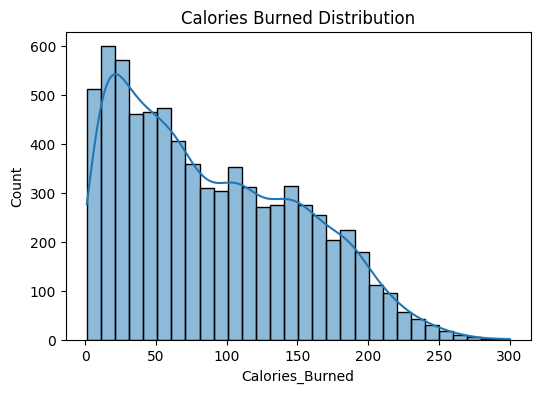

In [56]:
train_y.describe()
plt.figure(figsize=(6,4))
sns.histplot(train_y, bins=30, kde=True)
plt.title("Calories Burned Distribution")
plt.show()
#오른쪽 긴 꼬리 분포,, 로그변환하면 RMSE값 더 줄어들수도

# 베이스모델 로그변환

In [ ]:
# 로그변환 해보자
y_log = np.log1p(train_y)

# 데이터 다시 분리
X = train_x
y = y_log

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# LightGBM 다시 학습
model_lgbm = LGBMRegressor(random_state=42, n_estimators=1000)
model_lgbm.fit(X_train, y_train)

pred_log = model_lgbm.predict(X_val)

# 로그값 원래 스케일로 돌리기 로그 모델은 예측 후 expm1()안하면 의미없다!
pred = np.expm1(pred_log)
y_true = np.expm1(y_val)

# RMSE 계산
rmse_log = np.sqrt(mean_squared_error(y_true, pred))
print("LightGBM (log) RMSE:", rmse_log)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000441 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 292
[LightGBM] [Info] Number of data points in the train set: 6000, number of used features: 10
[LightGBM] [Info] Start training from score 4.154307
LightGBM (log) RMSE: 1.99251201147528


로그변환결과 RMSE값이 2.241560 -> 1.992512 약 0.25 감소했다.

큰 칼로리구간에서의 오차를 줄였음! 

이제부터 y = np.log1p(train_y) 이걸로 학습 시킬것

# 파생변수 생성

In [ ]:
y = np.log1p(train_y) #로그 타겟 고정

#===========파생변수 생성=============
# 총 운동 부하  강도 × 시간
train_x["Intensity"] = train_x["BPM"] * train_x["Exercise_Duration"] #train에 파생변수 Intensity 추가
test_x["Intensity"] = test_x["BPM"] * test_x["Exercise_Duration"]   #test에도 동일 

# train_x["Effort"] = train_x["Weight(lb)"] * train_x["Exercise_Duration"] * train_x["BPM"]
# test_x["Effort"] = test_x["Weight(lb)"] * test_x["Exercise_Duration"] * test_x["BPM"]

# # # Height 합치기 총 길이 = Feet*12 + Remainder_Inches
# train_x["Height_total"] = train_x["Height(Feet)"] * 12 + train_x["Height(Remainder_Inches)"]
# test_x["Height_total"] = test_x["Height(Feet)"] * 12 + test_x["Height(Remainder_Inches)"]

# # 총 에너지 소비량 (Intensity에 심박수까지 추가된거라 다중공선성 염려되지만.. lightgbm이니까 넣어서 해본다)
# train_x["Effort"] = (train_x["Weight(lb)"] * train_x["Exercise_Duration"] * train_x["BPM"])
# test_x["Effort"] = (test_x["Weight(lb)"] * test_x["Exercise_Duration"] * test_x["BPM"])

# # #  Duration 관련 
# train_x["Dur_x_Weight"] = train_x["Exercise_Duration"] * train_x["Weight(lb)"]
# test_x["Dur_x_Weight"]  = test_x["Exercise_Duration"] * test_x["Weight(lb)"]

# # BMI : BMI = 703 × weight(lb) / height(inches)^2 
# train_x['BMI'] = 703 * train_x['Weight(lb)'] / (train_x['Height_total']**2)
# test_x['BMI'] = 703 * test_x['Weight(lb)'] / (test_x['Height_total']**2)


# 파생변수 Intensity까지 포함된 X로 다시 지정
X = train_x

# 데이터 분리
X_train, X_val, y_train, y_val = train_test_split(  #train/val 분리
    X, y,
    test_size=0.2,
    random_state=42
)


# 학습 예측 아까 model_lgbm 그대로
model_lgbm.fit(X_train, y_train)
pred_log = model_lgbm.predict(X_val)
# 로그 → 원래 스케일로 복구 후 RMSE 계산
pred = np.expm1(pred_log)
y_true = np.expm1(y_val)
rmse = np.sqrt(mean_squared_error(y_true, pred))
print("LightGBM (log + 파생변수) RMSE:", rmse)



LightGBM (log + 파생변수) RMSE: 1.7990279115601655


In [129]:
# RMSE 파생변수 비교용 이미 생성된 파생변수 컬럼 제거
print(train_x.columns)
# drop_cols = ["Weight_Time", "Height_total", "Effort","Height_total","Dur_x_Weight","BMI", 'Dur_x_BPM', 'Dur_x_Intensity']
# train_x = train_x.drop(columns=[c for c in drop_cols if c in train_x.columns])
# test_x  = test_x.drop(columns=[c for c in drop_cols if c in test_x.columns])

Index(['Exercise_Duration', 'Body_Temperature(F)', 'BPM', 'Height(Feet)',
       'Height(Remainder_Inches)', 'Weight(lb)', 'Age', 'Gender_M',
       'Weight_Status_Obese', 'Weight_Status_Overweight', 'Intensity'],
      dtype='object')


In [109]:
missing_in_test = set(train_x.columns) - set(test_x.columns)
missing_in_train = set(test_x.columns) - set(train_x.columns)
print("missing_in_test:", missing_in_test)
print("missing_in_train:", missing_in_train)

missing_in_test: {'Dur_x_Intensity'}
missing_in_train: set()


기본모델 결과 :2.241

로그변환후 결과 : 1.992 

로그변환+ 파생변수Intensity 추가 후 결과: 1.805

파생변수가 모델 학습에 영향을 믾이 주는것같아 다양하게 만들어봐야겠디. 

파생변수 4개 넣고 돌렸을때 결과 : 1.8292 오히려 살짝 더 나빠짐.

로그 + Intensity (1.80) 가 제일 좋았었으니까 여기에 하나씩 추가해서 비교해보도록 함

비교결과 로그 + Intensity +Effort :1.7751132981807465 
이제 하이퍼파라미터 튜닝 해보겠음

# 하이퍼 파라미터 튜닝

In [110]:
#하이퍼파라미터 튜닝

# X는 train_x(파생변수 포함), y는 로그 타겟
y_log = np.log1p(train_y)

#RandomizedSearchCV가 실제 칼로리 단위 기준으로 평가하기 위한 변환하기 위한 함수 생성
def rmse_original_scale(y_true_log, y_pred_log):    #로그 상태의 실제값과 예측값을 받아서
    y_true = np.expm1(y_true_log)                   # 원래 스케일로 복구
    y_pred = np.expm1(y_pred_log)
    return np.sqrt(mean_squared_error(y_true, y_pred))  # kcal 기준 RMSE 계산

# sklearn은 점수가 클수록 좋다고 생각함 RMSE는 수치 적어야 좋은성능이니까 음수로 만듦
rmse_scorer = make_scorer(rmse_original_scale, greater_is_better=False)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        "random_state": 42,
        "n_estimators": 500,
        "n_jobs": 1,

        # Randomized best 근처를 타이트하게
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.06),
        "num_leaves": trial.suggest_int("num_leaves", 24, 40),
        "max_depth": trial.suggest_categorical("max_depth", [-1, 6, 8, 10]),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 25),

        "subsample": trial.suggest_float("subsample", 0.75, 0.95),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.85, 1.0),

        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 0.3),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 2.0),
    }

    model = LGBMRegressor(**params, verbose=-1 )  #verbose=-1이거 추가안하고 실행하면 스크롤 폭탄맞음 ..ㄹㅇ..

    scores = cross_val_score(
        model, train_x, y_log,
        scoring=rmse_scorer,  # kcal RMSE scorer (음수변환)
        cv=cv,
        n_jobs=-1
    )
    rmse = -scores.mean()  # 음수 -> 양수 RMSE로 다시 변환
    return rmse

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=80)

print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)





[I 2026-02-12 01:38:34,756] A new study created in memory with name: no-name-e828bf94-fe46-45ea-a837-4a6de6867689
[I 2026-02-12 01:38:35,377] Trial 0 finished with value: 2.5246603851616713 and parameters: {'learning_rate': 0.041236203565420876, 'num_leaves': 40, 'max_depth': -1, 'min_child_samples': 10, 'subsample': 0.923235229154987, 'colsample_bytree': 0.9401672517614813, 'reg_alpha': 0.21242177333881365, 'reg_lambda': 0.041168988591604894}. Best is trial 0 with value: 2.5246603851616713.
[I 2026-02-12 01:38:35,850] Trial 1 finished with value: 2.210558049559009 and parameters: {'learning_rate': 0.05909729556485983, 'num_leaves': 38, 'max_depth': 10, 'min_child_samples': 18, 'subsample': 0.8363890037284232, 'colsample_bytree': 0.8936843710297063, 'reg_alpha': 0.18355586841671384, 'reg_lambda': 0.27898772130408367}. Best is trial 1 with value: 2.210558049559009.
[I 2026-02-12 01:38:36,205] Trial 2 finished with value: 1.9282745218418988 and parameters: {'learning_rate': 0.03876433945

Best RMSE: 1.6004381653489386
Best params: {'learning_rate': 0.054072230579755555, 'num_leaves': 37, 'max_depth': -1, 'min_child_samples': 10, 'subsample': 0.819330341945987, 'colsample_bytree': 0.908599882128839, 'reg_alpha': 0.0012168161121796732, 'reg_lambda': 0.07921374753727463}


In [111]:
#베스트 파라미터 CV 재확인(안정적인지 확인하기)
best_params = study.best_params

model = LGBMRegressor(
    random_state=42,
    n_estimators=500,
    n_jobs=1,
    verbose=-1,
    **best_params
)

scores = cross_val_score(
    model,
    train_x,
    y_log,
    scoring=rmse_scorer,
    cv=cv,
    n_jobs=-1
)

print("Recheck CV RMSE mean:", -scores.mean())
print("Recheck CV RMSE std :", (-scores).std())



Recheck CV RMSE mean: 1.6004381653489386
Recheck CV RMSE std : 0.14295462982039717


In [117]:
#n_estimators만 키워보기
for n in [500, 800, 1200, 1500, 1800,2000]:
    model = LGBMRegressor(
        random_state=42,
        n_estimators=n,
        n_jobs=1,
        verbose=-1,
        **best_params
    )
    
    scores = cross_val_score(
        model,
        train_x,
        y_log,
        scoring=rmse_scorer,
        cv=cv,
        n_jobs=-1
    )
    
    print(f"n_estimators={n} → CV RMSE:", -scores.mean())

n_estimators=500 → CV RMSE: 1.6004381653489386
n_estimators=800 → CV RMSE: 1.4987372635702014
n_estimators=1200 → CV RMSE: 1.4532996621541443
n_estimators=1500 → CV RMSE: 1.4367967632991019
n_estimators=1800 → CV RMSE: 1.4249354407349144
n_estimators=2000 → CV RMSE: 1.4195357491390062


In [ ]:
#n=1500에서 fold별 RMSE와 std 확인
n = 1500
model = LGBMRegressor(
    random_state=42,
    n_estimators=n,
    n_jobs=1,
    verbose=-1,
    **best_params
)

scores = cross_val_score(model, train_x, y_log, scoring=rmse_scorer, cv=cv, n_jobs=-1)
rmse_folds = -scores

print("Fold RMSEs:", rmse_folds)
print("Mean RMSE :", rmse_folds.mean())
print("Std RMSE  :", rmse_folds.std())

Fold RMSEs: [1.68378244 1.28652242 1.35483949 1.41304204 1.35949236]
Mean RMSE : 1.4195357491390062
Std RMSE  : 0.1380955056763344


In [135]:
# Seed Ensemble - LightGBM은 seed 바꾸면 트리 분기 순서가 조금씩 달라짐.
# 이걸 평균내면 보통 RMSE 내려감 시도해본다.
cv = KFold(n_splits=5, shuffle=True, random_state=42)
seeds = [42, 52, 62, 72, 82]

fold_rmse = []

for train_idx, val_idx in cv.split(train_x):
    X_tr, X_val = train_x.iloc[train_idx], train_x.iloc[val_idx]
    y_tr, y_val = train_y.iloc[train_idx], train_y.iloc[val_idx]

    y_tr_log = np.log1p(y_tr)

    preds_val = []

    for seed in seeds:
        model = LGBMRegressor(
            random_state=seed,
            n_estimators=1500,
            n_jobs=-1,
            verbose=-1,
            **best_params
        )

        # fold train으로 학습
        model.fit(X_tr, y_tr_log)

        # fold val로 예측
        pred_val_log = model.predict(X_val)
        pred_val = np.expm1(pred_val_log)
        preds_val.append(pred_val)

    pred_val_mean = np.mean(preds_val, axis=0)

    rmse = np.sqrt(np.mean((y_val.values - pred_val_mean) ** 2))
    fold_rmse.append(rmse)

print("Seed Ensemble CV Mean:", np.mean(fold_rmse))
print("Seed Ensemble CV Std :", np.std(fold_rmse))
#튀는 fold 확인용
print("Fold RMSEs:", fold_rmse)
print("Mean:", np.mean(fold_rmse))
print("Std :", np.std(fold_rmse))


# 평균 앙상블
#final_pred = np.mean(preds, axis=0)

Seed Ensemble CV Mean: 1.2053019330048695
Seed Ensemble CV Std : 0.1974097404314939
Fold RMSEs: [np.float64(1.5865895030361117), np.float64(1.0498779321182055), np.float64(1.0791340340309383), np.float64(1.202508560605451), np.float64(1.108399635233641)]
Mean: 1.2053019330048695
Std : 0.1974097404314939


In [131]:
#최종 파라미터 고정
final_params = {
    "learning_rate": 0.05878700609192509,
    "num_leaves": 32,
    "max_depth": 8,
    "min_child_samples": 13,
    "subsample": 0.9252051762811434,
    "colsample_bytree": 0.9071376601278041,
    "reg_alpha": 0.0002260716835361878,
    "reg_lambda": 0.3269912384205852,
}

# 최종 모델 학습
y_log = np.log1p(train_y)

final_model = LGBMRegressor(
    random_state=42,
    n_estimators=1500,
    n_jobs=-1,     # 최종 학습은 빠르게
    verbose=-1,
    **final_params
)

final_model.fit(train_x, y_log)

pred_log = final_model.predict(test_x)
pred = np.expm1(pred_log)  # kcal로 복구

# submit / 제출

In [94]:
submission = pd.read_csv('sample_submission.csv')

In [ ]:
submission['Calories_Burned'] = pred

In [96]:
submission.to_csv('./submit.csv', index = False)